In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import datetime
import pytz

NYC_tz = pytz.timezone("America/New_York") 

import sys
sys.path.append("../../")

In [2]:
from MDP.STIRFutures.STIRFutureOptionMDP import STIRFutureOptionMDP
from Query.STIRFutureOptions.STIRFutureOptionQuery import STIRFutureOptionQuery
from Query.STIRFutureOptions.STIRFutureOptionStructure import STIRFutureOptionStructure
from Query.STIRFutureOptions.STIRFutureOptionValue import STIRFutureOptionValue

In [3]:
stirfo_mdp = STIRFutureOptionMDP(source="BARCHART_STIRFO-QL")

In [4]:
as_of = datetime.date(2026, 4, 27)
# as_of = "live"

q = STIRFutureOptionQuery(
    structure=STIRFutureOptionStructure.OUTRIGHT,
    value=STIRFutureOptionValue.PRICE,
    symbol="SFRZ26|25DC",  
    market_request={
        "endpoint": "option_snapshot",
        "timestamp": as_of,
        "use_ql_calculator": True,
        # "force_refresh": True,
    },
)

req = q.build_mdp_request(as_of)
pr = stirfo_mdp.get_pricer(req)

package, weights = q.resolve_package(pricer_or_curve=pr)
value_map = q.build_value_map(
    pricer_or_curve=pr,
    package=package,
    risk_weights=weights,
)

print("resolved_symbol:", package[0].symbol())
print("price:", value_map.apply(STIRFutureOptionValue.PRICE))
print("iv_normal_bps:", value_map.apply(STIRFutureOptionValue.IV_NORMAL_BPS))
print("delta:", value_map.apply(STIRFutureOptionValue.DELTA))
print("gamma:", value_map.apply(STIRFutureOptionValue.GAMMA))
print("vega:", value_map.apply(STIRFutureOptionValue.VEGA))
print("theta:", value_map.apply(STIRFutureOptionValue.THETA))

resolved_symbol: SFRZ26|9681C
price: 0.1075
iv_normal_bps: 85.85081170895931
delta: 0.25803151828163146
gamma: 0.46568022622186117
vega: 0.25520857321600954
theta: -0.16765111738386196


FETCHING EOD DATA FROM BARCHART...: 100%|██████████| 55/55 [00:13<00:00,  4.14it/s]


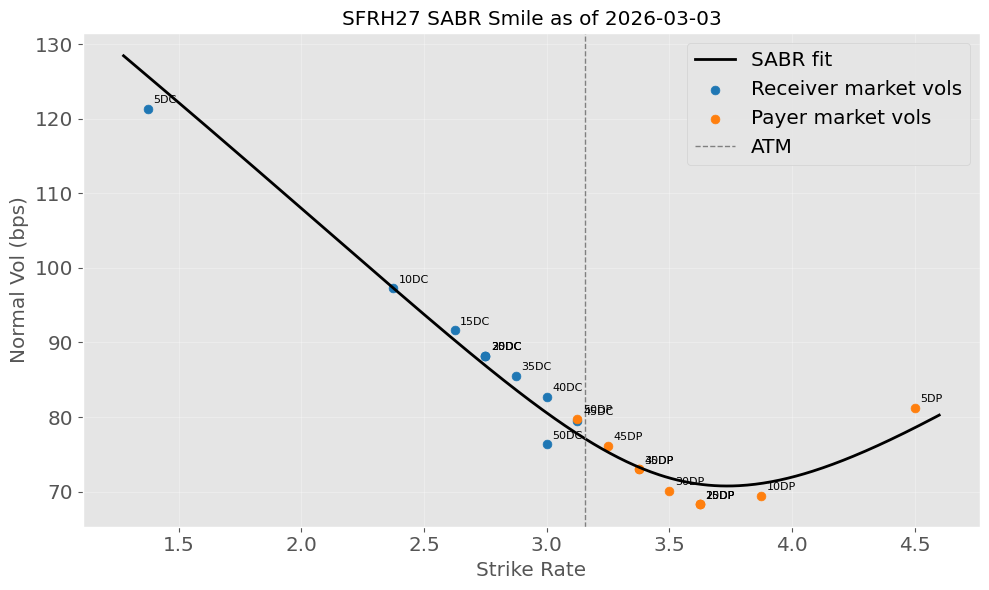

FETCHING EOD DATA FROM BARCHART...:   0%|          | 0/1 [03:50<?, ?it/s]


KeyboardInterrupt: 

2026-04-30 10:55:14,032 - BarchartFetcher - ERROR - Barchart EOD - Max retries exceeded for SQM27: SOCKSHTTPSConnectionPool(host='www.barchart.com', port=443): Max retries exceeded with url: /futures/quotes/SQM27/interactive-chart (Caused by NewConnectionError('<urllib3.contrib.socks.SOCKSHTTPSConnection object at 0x000001D5DF4DA990>: Failed to establish a new connection: SOCKS5 authentication failed'))
ERROR	Task(Task-237) BarchartFetcher:BarchartFetcher.py:_fetch_eod_timeseries()- Barchart EOD - Max retries exceeded for SQM27: SOCKSHTTPSConnectionPool(host='www.barchart.com', port=443): Max retries exceeded with url: /futures/quotes/SQM27/interactive-chart (Caused by NewConnectionError('<urllib3.contrib.socks.SOCKSHTTPSConnection object at 0x000001D5DF4DA990>: Failed to establish a new connection: SOCKS5 authentication failed'))


In [ ]:
from RVUtils.ImpliedDistribution import (
    SFRImpliedDistribution,
    FedScenarioConfig,
    plot_snapshot_dashboard,
    plot_rnd_comparison,
	plot_distribution_change,
	resolve_strip_symbols,
    plot_strip_distribution_change,
    plot_sfr_smile
)


config = FedScenarioConfig.default_sofr_scenarios(
    current_rate=3.64, n_cuts_range=[-1, 0, 1, 2, 3]
)
dist = SFRImpliedDistribution(scenario_config=config)

smile1 = stirfo_mdp.fetch_sabr_smile({
    "symbol": "SFRH27",
    "as_of": datetime.date(2026, 3, 3),
    # "strike_offsets_bps": "listed",
    # "force_refresh": True,
    "show_tqdm": True,
})
plot_sfr_smile(smile1)

smile2 = stirfo_mdp.fetch_sabr_smile({
    "symbol": "SFRM27",
    "as_of": datetime.date(2026, 3, 3),
    # "as_of": "live", 
    # "strike_offsets_bps": "listed",
    "show_tqdm": True,
})
plot_sfr_smile(smile2)

snap_before, snap_after = dist.compare(smile1, smile2)
fig = plot_distribution_change(snap_before, snap_after)

mean: 3.598263296353637
median: 3.5935584764368933
5th: 2.389803539009033
95th: 5.134961894574794
bin edges: [1.   1.25 1.5  1.75 2.   2.25 2.5  2.75 3.   3.25 3.5  3.75 4.   4.25
 4.5  4.75 5.   5.25 5.5  5.75 6.   6.25 6.5 ]
bin probabilities: [1.08280048e-04 2.08957066e-03 5.40658609e-03 9.56033509e-03
 1.72040125e-02 3.03977153e-02 4.93252954e-02 7.39867529e-02
 1.04382088e-01 1.40511300e-01 1.68631750e-01 1.49246446e-01
 9.72856499e-02 5.02519842e-02 2.07582698e-02 1.15928915e-02
 1.79972396e-02 2.07206896e-02 1.58424479e-02 3.68029640e-03
 0.00000000e+00 0.00000000e+00]


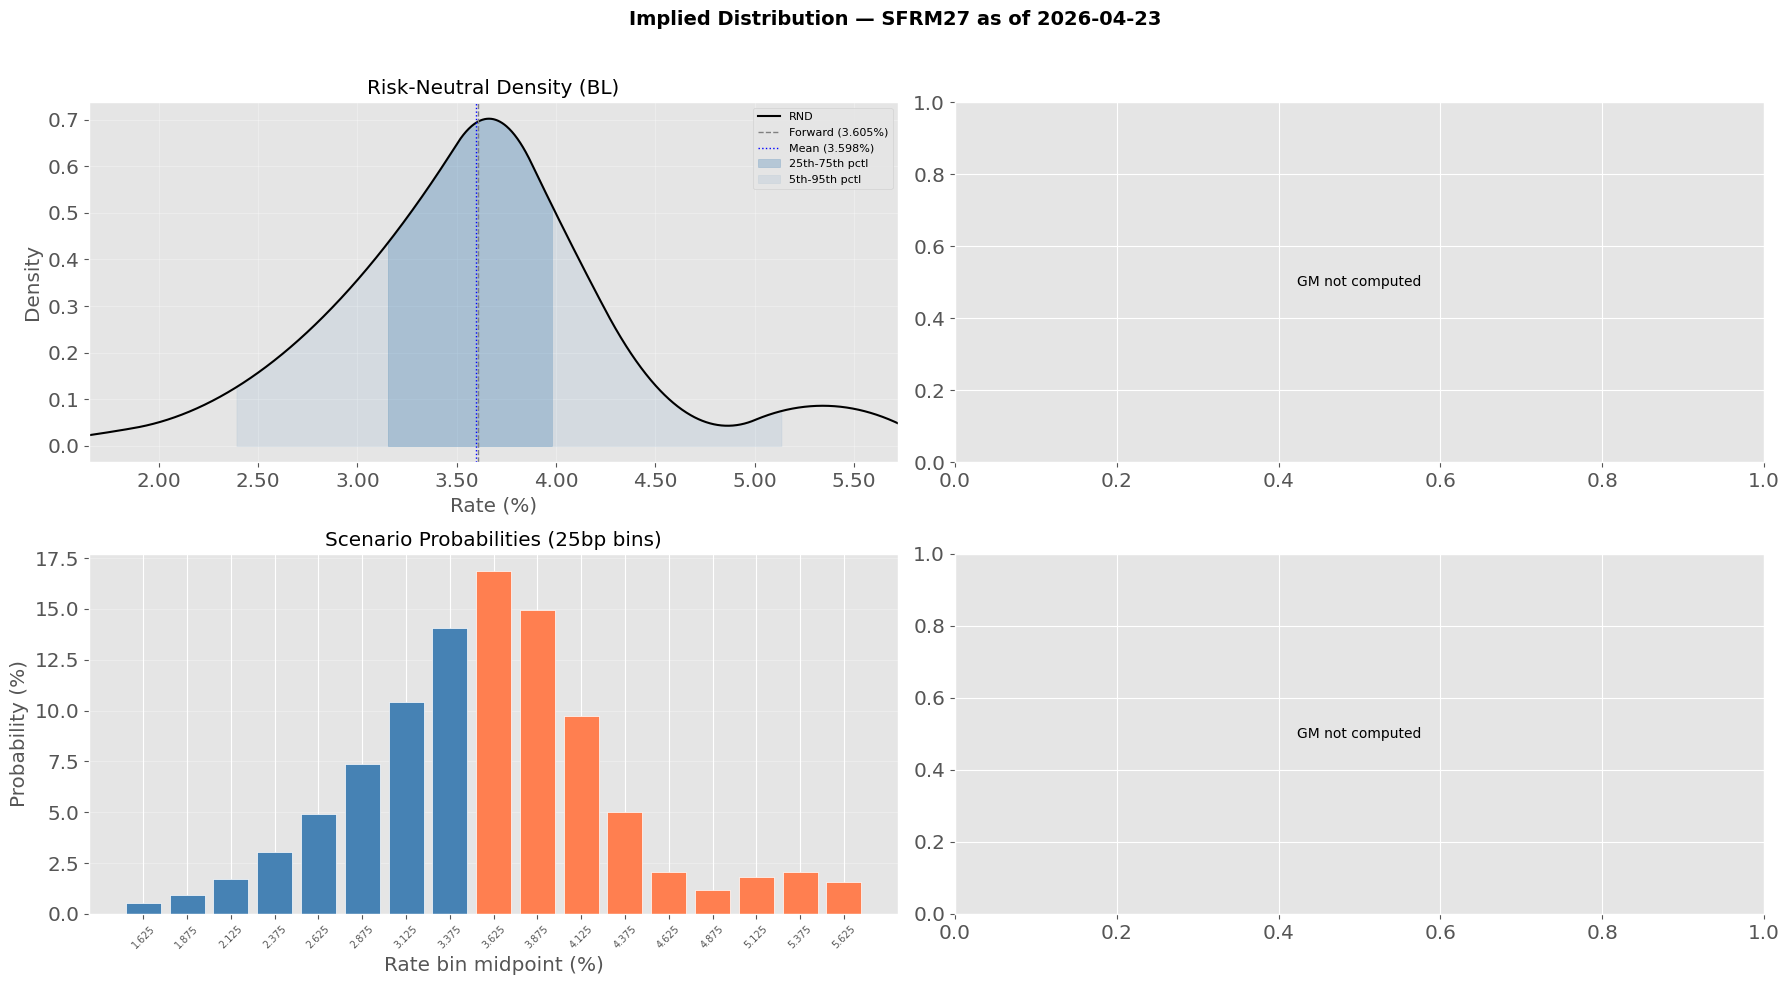

In [7]:
from RVUtils.ImpliedDistribution import SFRImpliedDistribution, plot_snapshot_dashboard

smile = stirfo_mdp.fetch_sabr_smile({
    "symbol": "SFRM27",
    "as_of": datetime.date(2026, 4, 23),
    "strike_offsets_bps": "listed",
    "show_tqdm": True,
})

# Default is raw JPM-style BL:
# observed OTM premiums, OI >= 100, put-call parity, 25bp bins
dist = SFRImpliedDistribution()

snapshot = dist.extract(smile, run_gm=False)
bl = snapshot.bl_result

print("mean:", bl.mean_rate)
print("median:", bl.percentile(50))
print("5th:", bl.percentile(5))
print("95th:", bl.percentile(95))
print("bin edges:", bl.bin_edges_rate)
print("bin probabilities:", bl.bin_probabilities)

a = plot_snapshot_dashboard(snapshot)

In [9]:
"""Confirm SABR smile caching at the MDP layer.

First call fetches from Barchart (slow). Second call hits the disk cache
(instant). Third call with force_refresh=True bypasses cache and re-fetches.
"""
import datetime
import time

from MDP.STIRFutures.STIRFutureOptionMDP import STIRFutureOptionMDP

opt_mdp = STIRFutureOptionMDP(source="BARCHART_STIRFO-QL")

req = {
    "symbol": "SFRZ26",
    "as_of": datetime.date(2026, 4, 28),
    # "strike_offsets_bps": "listed",   # full CME-listed grid (~30-50 strikes)
    "deltas": [5, 10, 15, 20, 25, 30, 35, 40, 45, 50],  # alt: sparse delta grid
}

# 1. cold fetch -- hits Barchart for every strike + calibrates SABR
t0 = time.monotonic()
smile1 = opt_mdp.fetch_sabr_smile(req)
t_cold = time.monotonic() - t0
print(f"[cold]   {t_cold:6.2f}s  symbol={smile1.symbol}  n_points={len(smile1.points)}")
print(f"         params: alpha={smile1.params.alpha:.4f}  beta={smile1.params.beta}  "
      f"rho={smile1.params.rho:.4f}  nu={smile1.params.nu:.4f}")

# 2. warm fetch -- same request, served from disk cache (no Barchart traffic)
t0 = time.monotonic()
smile2 = opt_mdp.fetch_sabr_smile(req)
t_warm = time.monotonic() - t0
print(f"[warm]   {t_warm:6.2f}s  cache hit -> {t_cold/max(t_warm,1e-6):.0f}x faster")

# 3. force_refresh -- bypasses cache, re-fetches from Barchart
t0 = time.monotonic()
smile3 = opt_mdp.fetch_sabr_smile({**req, "force_refresh": True})
t_force = time.monotonic() - t0
print(f"[force]  {t_force:6.2f}s  bypassed cache, re-fetched from Barchart")

# 4. confirm the cached object round-trips losslessly
assert smile1.symbol == smile2.symbol
assert smile1.params.alpha == smile2.params.alpha
assert tuple(p.strike for p in smile1.points) == tuple(p.strike for p in smile2.points)
print(f"\n[ok]     cold/warm SABR params + strike list identical")

# 5. inspect the cache directory directly
import os
from pathlib import Path
cache_dir = Path(os.environ["LOCALAPPDATA"]) / "ARBS" / "Cache" / "diskcache" / "dump" / "STIRFutureOptionPricer_Cache"
mb = sum(p.stat().st_size for p in cache_dir.rglob("*") if p.is_file()) / (1024**2)
print(f"[disk]   {cache_dir} -> {mb:.1f} MB on disk")

[cold]     2.74s  symbol=SFRZ26  n_points=20
         params: alpha=0.0692  beta=0.5  rho=-0.0075  nu=1.4992
[warm]     0.00s  cache hit -> 2025x faster
[force]   56.95s  bypassed cache, re-fetched from Barchart


AttributeError: 'STIRFutureOptionSmilePoint' object has no attribute 'strike'